## Imports y carga de datos


In [1]:
import numpy as np
import jax
import jax.numpy as jnp
from jax import grad, jit
import matplotlib.pyplot as plt

data = np.load("datos_6111.npz")
X, y, t = data["X"], data["y"], data["t"]   # X: (24,256), y: (24,), t: (256,)
print(X.shape, y.shape, t.shape)

K = 15
N = X.shape[1]   # 256


(24, 256) (24,) (256,)


In [2]:
# Configuracion global de estilo para todas las figuras del notebook
plt.rcParams.update({
    "text.usetex": False,           # mathtext interno: no requiere instalacion de LaTeX
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"], # cobertura Unicode completa (tildes, ñ); cmr10 no las tiene
    "mathtext.fontset": "cm",       # estilo Computer Modern solo para formulas ($...$)
    "axes.formatter.use_mathtext": True,
    "font.size": 16,

    # Ejes y Ticks
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction": "in",
    "ytick.direction": "in",

    # Grid
    "grid.color"    : "gray",
    "grid.linewidth": 0.3,
    "grid.alpha"    : 0.3,
    "grid.linestyle": "--",

    # Estetica
    "figure.dpi"        : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "savefig.bbox"      : "tight",
    "savefig.dpi"       : 300,
})

In [3]:

print("Clase de X:", type(X))
print("Tamaño:", X.shape[0])
print("N :", N)

print("X.shape =", X.shape)

print("X[0].shape =", X[0].shape)
print("X[1].shape =", X[1].shape)

print(len(X[0]), len(X[1]))

Clase de X: <class 'numpy.ndarray'>
Tamaño: 24
N : 256
X.shape = (24, 256)
X[0].shape = (256,)
X[1].shape = (256,)
256 256


## Parte 1 — Capa Fourier 
Construcción de W1​ (Fourier)

In [4]:
def construir_W1_fourier(t, K):
    """
    Filas 0..K-1   -> sin(2*pi*k*t)
    Filas K..2K-1  -> cos(2*pi*k*t)
    Retorna matriz (2K, N)
    """
    ks = jnp.arange(1, K + 1)[:, None]      # (K,1)
    tt = t[None, :]                          # (1,N)
    senos  = jnp.sin(2 * jnp.pi * ks * tt)   # (K,N)
    cosenos = jnp.cos(2 * jnp.pi * ks * tt)  # (K,N)
    return jnp.concatenate([senos, cosenos], axis=0)  # (2K,N)

W1_fourier = construir_W1_fourier(jnp.array(t), K)
print(W1_fourier.shape)  # (30, 256)

(30, 256)


Verificación contra np.fft
La idea: al proyectar una señal con W1FourierW_1^{Fourier}
W1Fourier​ obtienes (salvo escala) las partes real e imaginaria de su transformada de Fourier en esas mismas frecuencias k.

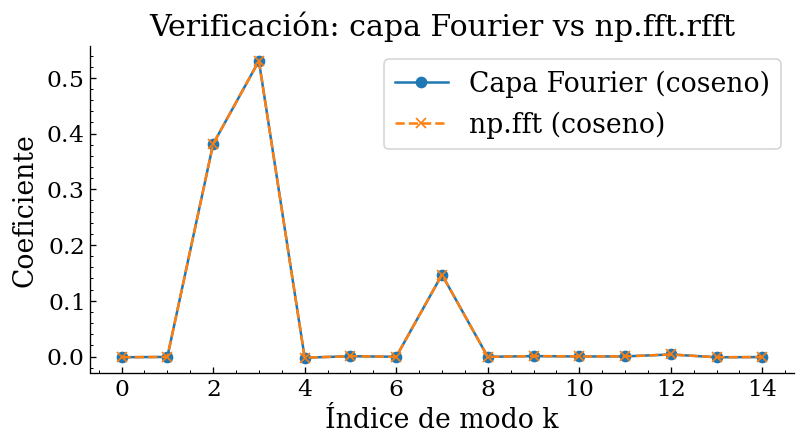

In [5]:
señal_prueba = X[0]
proy = W1_fourier @ señal_prueba   # (30,)

fft_ref = np.fft.rfft(señal_prueba)  # complejo, longitud N/2+1
#print(fft_ref)
# Comparamos componente k=1..K (ignorando k=0, la DC)
coef_coseno_manual = proy[K:] * (2 / N)   # filas de coseno
coef_seno_manual   = proy[:K] * (2 / N)   # filas de seno

coef_coseno_fft = fft_ref.real[1:K+1] * (2 / N)
coef_seno_fft   = -fft_ref.imag[1:K+1] * (2 / N)   # signo por convención

plt.figure(figsize=(7,4))
plt.plot(coef_coseno_manual, 'o-', label="Capa Fourier (coseno)")
plt.plot(coef_coseno_fft, 'x--', label="np.fft (coseno)")
plt.xlabel("Índice de modo k")
plt.ylabel("Coeficiente")
plt.title("Verificación: capa Fourier vs np.fft.rfft")
plt.legend()
plt.tight_layout()
plt.show()

**Figura 1.** Coeficientes coseno ($k=1,\dots,15$) obtenidos al proyectar la primera señal del dataset sobre las filas coseno de la capa Fourier $W_1^{Fourier}$ (círculos), comparados con los coeficientes equivalentes calculados con `np.fft.rfft` (cruces), ambos normalizados por $2/N$. La coincidencia punto a punto entre las dos curvas confirma que, en su punto de partida, la capa lineal $W_1^{Fourier}$ calcula efectivamente la transformada de Fourier discreta de la señal de entrada.

Energía media del dataset

In [6]:
energia_media = (X**2).mean()
print(f"Energía media del dataset: {energia_media:.3f}")

Energía media del dataset: 0.673


## Parte 2 — Red, entrenamiento y reconstrucción

**Arquitectura y pérdida**

In [7]:
def forward(params, x):
    W1, W2 = params
    h = jnp.tanh(W1 @ x)
    return W2 @ h

def loss_fn(params, X):
    preds = jax.vmap(lambda x: forward(params, x))(X)
    return jnp.mean((preds - X)**2)

loss_grad = jit(grad(loss_fn))
loss_jit  = jit(loss_fn)

**Las dos inicializaciones**

In [8]:
key = jax.random.PRNGKey(0)

# W2 se inicializa igual en ambos casos (aleatoria pequeña)
key, subkey = jax.random.split(key)
W2_init = jax.random.normal(subkey, (N, 2*K)) * 0.05

# Init Fourier
params_fourier = (W1_fourier, W2_init)

# Init aleatoria
key, subkey = jax.random.split(key)
W1_random = jax.random.normal(subkey, (2*K, N)) * 0.05
params_random = (W1_random, W2_init)

**Bucle de entrenamiento (gradiente descendente simple)**

In [9]:
def entrenar(params, X, eta=0.1, iteraciones=2000):
    historia_loss = []
    for i in range(iteraciones):
        l = loss_jit(params, X)
        historia_loss.append(l)
        grads = loss_grad(params, X)
        params = tuple(p - eta * g for p, g in zip(params, grads))
    return params, jnp.array(historia_loss)

X_jax = jnp.array(X)

params_fourier_final, loss_fourier = entrenar(params_fourier, X_jax)
params_random_final,  loss_random  = entrenar(params_random,  X_jax)

**Gráfica: señal original vs reconstrucción (una por régimen)**

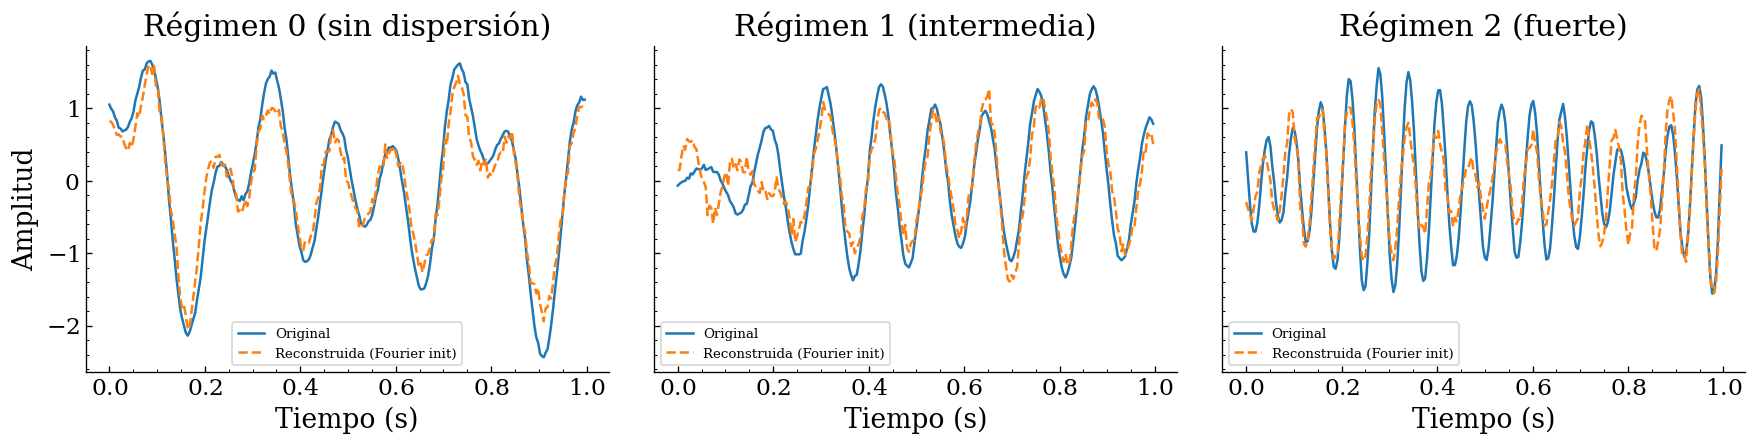

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15,4), sharey=True)
nombres_regimen = ["Régimen 0 (sin dispersión)", "Régimen 1 (intermedia)", "Régimen 2 (fuerte)"]

for r in range(3):
    idx = np.where(y == r)[0][0]   # primera señal de ese régimen
    x_orig = X[idx]
    x_hat = forward(params_fourier_final, jnp.array(x_orig))

    axes[r].plot(t, x_orig, label="Original", lw=1.5)
    axes[r].plot(t, x_hat, '--', label="Reconstruida (Fourier init)", lw=1.5)
    axes[r].set_title(nombres_regimen[r])
    axes[r].set_xlabel("Tiempo (s)")
    if r == 0:
        axes[r].set_ylabel("Amplitud")
    axes[r].legend(fontsize=8)

plt.tight_layout()
plt.show()

**Figura 2.** Señal original (línea sólida) y reconstrucción $\hat x = W_2\tanh(W_1 x)$ de la red con inicialización Fourier tras 2000 iteraciones de entrenamiento (línea discontinua), para una señal representativa de cada régimen de dispersión ($\mu$ creciente de izquierda a derecha). El eje horizontal es el tiempo en segundos y el vertical la amplitud de la señal; los tres paneles comparten la misma escala vertical para facilitar la comparación entre regímenes. 

**Error de reconstrucción relativo**

In [11]:
def error_relativo(params, x):
    x_hat = forward(params, x)
    return jnp.linalg.norm(x_hat - x) / jnp.linalg.norm(x)

for r in range(3):
    idx = np.where(y == r)[0][0]
    x = jnp.array(X[idx])
    err_f = error_relativo(params_fourier_final, x)
    err_r = error_relativo(params_random_final, x)
    print(f"Régimen {r}: error Fourier={err_f:.4f}, error aleatoria={err_r:.4f}")

Régimen 0: error Fourier=0.2730, error aleatoria=0.2536
Régimen 1: error Fourier=0.4339, error aleatoria=0.3290
Régimen 2: error Fourier=0.5058, error aleatoria=0.3900


## Parte 3 — Comparación de inicializaciones
**Curvas de pérdida superpuestas**

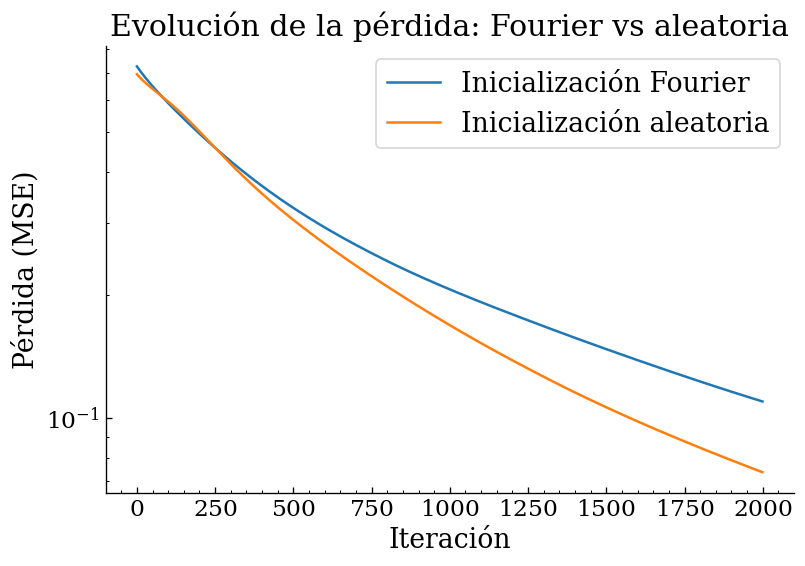

In [12]:
plt.figure(figsize=(7,5))
plt.plot(loss_fourier, label="Inicialización Fourier")
plt.plot(loss_random, label="Inicialización aleatoria")
plt.xlabel("Iteración")
plt.ylabel("Pérdida (MSE)")
plt.yscale("log")
plt.title("Evolución de la pérdida: Fourier vs aleatoria")
plt.legend()
plt.tight_layout()
plt.show()

**Figura 3.** Evolución de la pérdida de entrenamiento (MSE, eje vertical en escala logarítmica) en función del número de iteraciones de descenso de gradiente, para la inicialización con la base de Fourier y para la inicialización aleatoria de $W_1$. Ambas curvas se calculan sobre las 24 señales del dataset (los tres regímenes combinados), con la misma tasa de aprendizaje $\eta=0.1$. La brecha entre ambas curvas en las primeras iteraciones evidencia qué tan rápido converge cada inicialización antes de que ambas tiendan a un comportamiento similar.

### Iteraciones para bajar de error relativo 0.1
Para esto conviene registrar el error relativo (no solo loss) en cada iteración:

In [13]:
def entrenar_con_error(params, X, eta=0.1, iteraciones=2000):
    historia_loss = []
    historia_err = []
    for i in range(iteraciones):
        l = loss_jit(params, X)
        preds = jax.vmap(lambda x: forward(params, x))(X)
        err = jnp.linalg.norm(preds - X) / jnp.linalg.norm(X)
        historia_loss.append(l)
        historia_err.append(err)
        grads = loss_grad(params, X)
        params = tuple(p - eta * g for p, g in zip(params, grads))
    return params, jnp.array(historia_loss), jnp.array(historia_err)

params_fourier_final, loss_f, err_f = entrenar_con_error(params_fourier, X_jax)
params_random_final, loss_r, err_r = entrenar_con_error(params_random, X_jax)

def iteracion_umbral(err_hist, umbral=0.1):
    idx = jnp.argmax(err_hist < umbral)
    return idx if err_hist[idx] < umbral else None  # None = nunca bajó del umbral

it_f = iteracion_umbral(err_f)
it_r = iteracion_umbral(err_r)
print(f"Fourier baja de 0.1 en la iteración: {it_f}")
print(f"Aleatoria baja de 0.1 en la iteración: {it_r}")

Fourier baja de 0.1 en la iteración: None
Aleatoria baja de 0.1 en la iteración: None


### Régimen difícil (régimen 0)

In [14]:
mask_r0 = (y == 0)
X_r0 = X_jax[mask_r0]

# Reentrena solo con régimen 0, o evalúa el error solo sobre ese subconjunto durante el entrenamiento ya hecho
err_f_r0 = jnp.linalg.norm(
    jax.vmap(lambda x: forward(params_fourier_final, x))(X_r0) - X_r0
) / jnp.linalg.norm(X_r0)

err_r_r0 = jnp.linalg.norm(
    jax.vmap(lambda x: forward(params_random_final, x))(X_r0) - X_r0
) / jnp.linalg.norm(X_r0)

print(f"Régimen 0 — error final Fourier: {err_f_r0:.4f}, aleatoria: {err_r_r0:.4f}")

Régimen 0 — error final Fourier: 0.3441, aleatoria: 0.3187


## Parte 4 — Compresión 

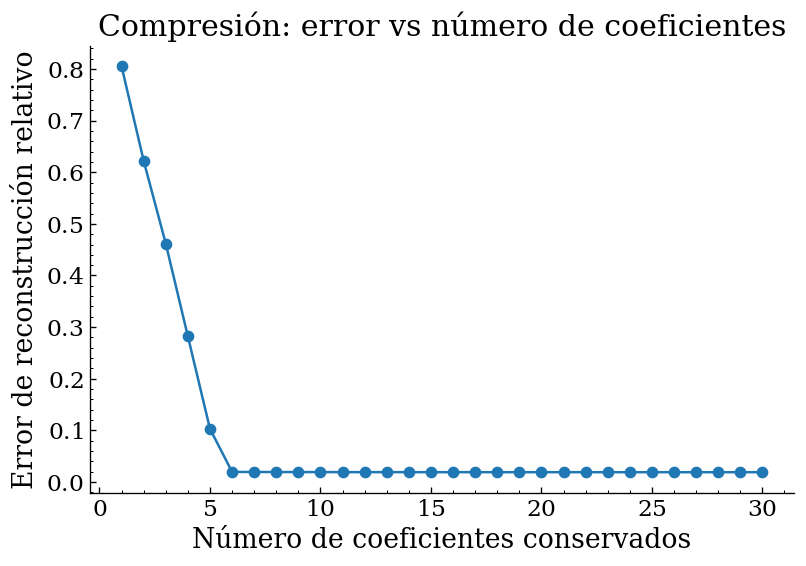

Coeficientes necesarios para 85% de la energía: 4


In [15]:
# Reconstrucción truncando coeficientes de Fourier (no de la red entrenada, sino de la transformada pura)
def reconstruir_con_m_coef(x, W1_fourier, m):
    coef = W1_fourier @ x
    coef_truncado = jnp.zeros_like(coef)
    # conserva los m coeficientes de mayor magnitud
    idx_top = jnp.argsort(jnp.abs(coef))[-m:]
    coef_truncado = coef_truncado.at[idx_top].set(coef[idx_top])
    # reconstrucción aproximada (pseudo-inversa de W1_fourier)
    W1_pinv = jnp.linalg.pinv(W1_fourier)
    return W1_pinv @ coef_truncado

errores_m = []
ms = range(1, 2*K + 1)
x_ejemplo = X_jax[0]

for m in ms:
    x_hat = reconstruir_con_m_coef(x_ejemplo, W1_fourier, m)
    err = jnp.linalg.norm(x_hat - x_ejemplo) / jnp.linalg.norm(x_ejemplo)
    errores_m.append(err)

plt.figure(figsize=(7,5))
plt.plot(ms, errores_m, 'o-')
plt.xlabel("Número de coeficientes conservados")
plt.ylabel("Error de reconstrucción relativo")
plt.title("Compresión: error vs número de coeficientes")
plt.tight_layout()
plt.show()

# Coeficientes necesarios para 85% de energía
coef = W1_fourier @ x_ejemplo
energia_total = jnp.sum(coef**2)
coef_ordenado = jnp.sort(jnp.abs(coef))[::-1]
energia_acum = jnp.cumsum(coef_ordenado**2) / energia_total
m_85 = jnp.argmax(energia_acum >= 0.85) + 1
print(f"Coeficientes necesarios para 85% de la energía: {m_85}")

**Figura 4.** Error de reconstrucción relativo $\|\hat x - x\|/\|x\|$ al conservar únicamente los $m$ coeficientes de la transformada de Fourier de mayor magnitud (de un total de $2K=30$) y reconstruir mediante la pseudo-inversa de $W_1^{Fourier}$, para una señal de ejemplo del dataset. El decaimiento rápido del error muestra que la mayor parte de la energía de la señal está concentrada en pocos modos de Fourier, consistente con el número de coeficientes necesario para alcanzar el 85 % de la energía total reportado a continuación.